# SPRINT 2: Pré-Processamento e Feature Engineering

**Equipe:** Grupo 05

## SEÇÃO 1: REVISÃO E CARREGAMENTO
Nesta secção, iniciamos a fase de preparação de dados recapitulando os principais problemas identificados na base de dados durante a Análise Exploratória (EDA) da Sprint 1, e carregamos os dados brutos para iniciar o tratamento.

### Principais Desafios Mapeados na Sprint 1:
1. **Outliers Severos:** Identificámos que a nossa variável alvo (`price_usd`) possui ruídos significativos, incluindo jogos gratuitos ($0.00) e títulos premium extremos (>$100.00), que distorcem a média.
2. **Valores Ausentes (Missing Values):** Colunas cruciais, em especial o `metacritic_score`, possuem lacunas que necessitam de estratégias de imputação ou remoção.
3. **Complexidade Categórica (Encoding):** O *dataset* possui variáveis em formato de texto (Géneros, Publicadoras, Categorias) que precisam de ser transformadas em representações numéricas para serem legíveis pelo algoritmo de *Machine Learning*.

In [2]:
import pandas as pd
import numpy as np

# Configuração para exibir todas as colunas no VS Code/Colab
pd.set_option('display.max_columns', None)

print("--- 1. CARREGAMENTO DOS DADOS BRUTOS ---")

# Link RAW do vosso repositório no GitHub (garantindo a reprodutibilidade)
url_github = 'https://raw.githubusercontent.com/JoaoDysarz/steam-price-prediction/main/data/Sprint_01/steam_top_games_2026.csv'

# Carregando o dataset original (bruto)
df_raw = pd.read_csv(url_github)

print(f"Dataset bruto carregado")
print(f"➜ Total de Linhas (Jogos): {df_raw.shape[0]}")
print(f"➜ Total de Colunas (Features): {df_raw.shape[1]}\n")

# Fazemos uma cópia de segurança para o processamento, mantendo o df_raw intacto
df_processado = df_raw.copy()

# Exibindo as primeiras linhas
df_processado.head()

--- 1. CARREGAMENTO DOS DADOS BRUTOS ---
Dataset bruto carregado
➜ Total de Linhas (Jogos): 1495
➜ Total de Colunas (Features): 29



,app_id,name,release_date,coming_soon,price_usd,is_free,discount_pct,developer,publisher,genres,categories,tags,platforms_win,platforms_mac,platforms_linux,metacritic_score,recommendations,positive_reviews,negative_reviews,estimated_owners,avg_playtime_forever,avg_playtime_2weeks,median_playtime,peak_ccu,required_age,dlc_count,achievements,short_description,header_image
0,794260,Outward Definitive Edition,"May 17, 2022",False,4.79,False,88,Nine Dots Studio,"Prime Matter, Deep Silver",RPG,"Single-player, Multi-player, Co-op, Online Co-...","RPG, Open World, Survival, Co-op, Online Co-Op...",True,False,False,NaN,23986,20738,7717,"1,000,000 .. 2,000,000",1332,824,465,469,0,1,72,No remarkable journey is achieved without grea...,https://shared.akamai.steamstatic.com/store_it...
1,253920,Gorky 17,"Sep 27, 2013",False,9.99,False,0,Metropolis Software,TopWare Interactive,"RPG, Strategy","Single-player, Steam Trading Cards, Family Sha...","RPG, Strategy, Turn-Based, Classic, Horror, Po...",True,True,True,NaN,909,1616,411,"200,000 .. 500,000",301,0,328,61,17,2,0,November 2008. NATO intelligence services repo...,https://shared.akamai.steamstatic.com/store_it...
2,613010,Secret in Story,"Jun 19, 2017",False,0.89,False,10,Naivus Luo,Naivus Luo,"Adventure, Indie","Single-player, Steam Achievements, Steam Tradi...","Indie, Adventure, Visual Novel",True,True,False,NaN,0,79,35,"2,000,000 .. 5,000,000",251,0,243,0,0,0,32,"Accompanied by beautiful piano music, you begi...",https://shared.akamai.steamstatic.com/store_it...
3,892420,懒人修仙传,"Nov 14, 2018",False,3.99,False,0,托更的修罗,托更的修罗,"Casual, Indie, RPG, Simulation","Single-player, Family Sharing","Simulation, Casual, RPG, Indie, Word Game, Idler",True,False,False,NaN,1169,769,509,"200,000 .. 500,000",5786,0,9223,41,0,0,0,这是一款很&quot;休闲&quot;的文字挂机游戏，游戏小而系统完善，玩法丰富，极其耗电，...,https://shared.akamai.steamstatic.com/store_it...
4,914010,Train Station Renovation,"Oct 1, 2020",False,18.99,False,0,Live Motion Games,"Live Motion Games, Frozen Way, PlayWay S.A., F...","Casual, Indie, Simulation","Single-player, Steam Achievements, Steam Cloud...","Simulation, Casual, Indie, Trains, First-Perso...",True,False,False,68.0,1948,2154,466,"200,000 .. 500,000",448,0,201,16,0,1,73,"Welcome to an old, ruined train station. A pla...",https://shared.akamai.steamstatic.com/store_it...


## SEÇÃO 2: TRATAMENTO DE DADOS NULOS

**Objetivo:** Garantir que o dataset não possui valores em branco (NaN) que façam o algoritmo de *Machine Learning* quebrar, aplicando estratégias adequadas para cada tipo de variável.

### Decisões e justificativas:
1. **Remoção de Variáveis Irrelevantes:** As colunas `app_id` (identificador aleatório), `name` (texto livre) e `header_image` (URL de imagem) não possuem qualquer poder preditivo matemático. Mantê-las apenas aumentaria o custo computacional. Serão removidas.
2. **Nulos Residuais (Linhas):** Variáveis categóricas importantes como `genres`, `developer` e `publisher` possuem menos de 1% de dados nulos. A exclusão destas poucas linhas (`.dropna()`) é a decisão mais segura, pois não compromete o volume estatístico da base.
3. **A Estratégia do Metacritic (Imputação adiada):** A coluna `metacritic_score` apresenta ~57% de dados nulos. 
    * *Porquê não excluir a coluna?* Porque provámos na Sprint 1 (Hipótese 2) que ela é uma excelente preditora para jogos caros.

In [3]:
print("--- 2. TRATAMENTO DE NULOS E LIMPEZA INICIAL ---")

# 1. Remoção de colunas que não agregam valor preditivo
colunas_para_remover = ['app_id', 'name', 'header_image', 'short_description']

# Adicionamos tags, categories e estimated_owners pois têm cardinalidade extrema ou formatos sujos
colunas_para_remover.extend(['tags', 'categories', 'estimated_owners', 'release_date_formatada'])

# Removendo do df_processado (verificando se existem antes de dar drop)
colunas_alvo = [col for col in colunas_para_remover if col in df_processado.columns]
df_processado = df_processado.drop(columns=colunas_alvo)

print(f"Colunas removidas com sucesso: {colunas_alvo}\\n")

# 2. Remoção de linhas com nulos nas variáveis categóricas (Nulos Residuais)
# Vamos listar as colunas textuais essenciais
colunas_categoricas = ['genres', 'publisher', 'developer', 'release_date']

antes_drop = len(df_processado)
df_processado = df_processado.dropna(subset=colunas_categoricas)
depois_drop = len(df_processado)

print(f"Linhas removidas devido a nulos residuais: {antes_drop - depois_drop}")
print(f"Tamanho atual do Dataset: {depois_drop} linhas.\\n")

# 3. Auditoria final de nulos
print("--- AUDITORIA DE NULOS ATUAL ---")
nulos_restantes = df_processado.isnull().sum()
nulos_restantes = nulos_restantes[nulos_restantes > 0]
print(nulos_restantes)
print("\\nNota: É esperado e proposital que o 'metacritic_score' e 'release_year' ainda tenham nulos aqui. Serão tratados via Pipeline e Feature Engineering.")

--- 2. TRATAMENTO DE NULOS E LIMPEZA INICIAL ---
Colunas removidas com sucesso: ['app_id', 'name', 'header_image', 'short_description', 'tags', 'categories', 'estimated_owners']\n
Linhas removidas devido a nulos residuais: 30
Tamanho atual do Dataset: 1465 linhas.\n
--- AUDITORIA DE NULOS ATUAL ---
metacritic_score    936
dtype: int64
\nNota: É esperado e proposital que o 'metacritic_score' e 'release_year' ainda tenham nulos aqui. Serão tratados via Pipeline e Feature Engineering.


## SEÇÃO 3: TRATAMENTO DE OUTLIERS

**Objetivo:** Limpar valores extremos da variável alvo (`price_usd`), garantindo a qualidade do modelo sem perder o contexto do mercado.

### Decisões de Negócio:
1. **Remoção de Jogos Gratuitos:** Jogos com preço $0.00 (Free-to-Play) distorcem a média e pertencem a um modelo de rentabilização diferente. Foram removidos para focar na previsão de preços de "prateleira".
2. **Corte de Preços Extremos (Ajuste de Negócio):** Inicialmente, a técnica de IQR sugeriu cortar preços acima de ~$30. No entanto, do ponto de vista de negócio, isso eliminaria os jogos "AAA" (alto orçamento). Optámos por substituir o rigor estatístico por um teto de mercado (USD 90.00). Assim, removemos apenas edições *premium* fora da curva ou erros de *input*, mas garantimos que a nossa Inteligência Artificial aprende a precificar grandes lançamentos.

--- 3. TRATAMENTO DE OUTLIERS NO PREÇO ---
Jogos gratuitos removidos: 365
Jogos com preços irreais (acima de USD 90.00) removidos: 1
Tamanho do dataset após a limpeza: 1099 linhas.



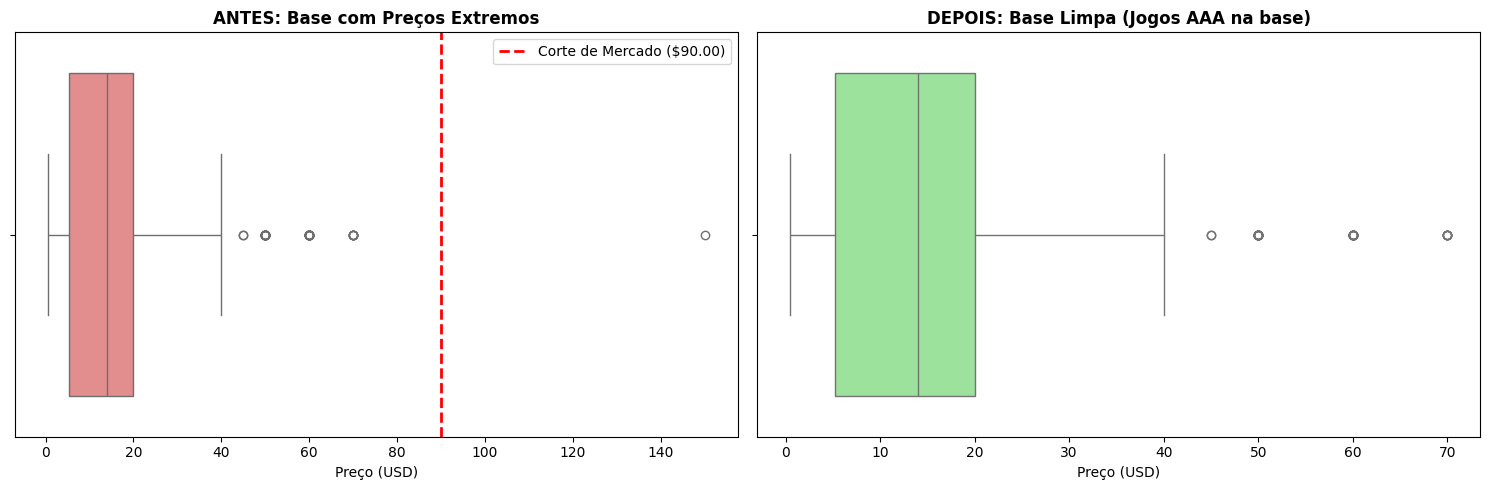

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 3. TRATAMENTO DE OUTLIERS NO PREÇO ---")
tamanho_antes = len(df_processado)

# 1. Removendo jogos gratuitos
df_processado = df_processado[df_processado['price_usd'] > 0]
jogos_pagos = len(df_processado)
print(f"Jogos gratuitos removidos: {tamanho_antes - jogos_pagos}")

# 2. Aplicando o teto de mercado (Mantendo os AAA, removendo absurdos)
limite_superior = 90.00
df_limpo = df_processado[df_processado['price_usd'] <= limite_superior]
depois_outliers = len(df_limpo)

print(f"Jogos com preços irreais (acima de USD {limite_superior:.2f}) removidos: {jogos_pagos - depois_outliers}")
print(f"Tamanho do dataset após a limpeza: {depois_outliers} linhas.\n")

# Visualização: Antes vs Depois
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df_processado, x='price_usd', color='lightcoral', ax=axes[0])
axes[0].set_title('ANTES: Base com Preços Extremos', fontweight='bold')
axes[0].set_xlabel('Preço (USD)')
axes[0].axvline(limite_superior, color='red', linestyle='--', linewidth=2, label=f'Corte de Mercado (${limite_superior:.2f})')
axes[0].legend()

sns.boxplot(data=df_limpo, x='price_usd', color='lightgreen', ax=axes[1])
axes[1].set_title('DEPOIS: Base Limpa (Jogos AAA na base)', fontweight='bold')
axes[1].set_xlabel('Preço (USD)')

plt.tight_layout()
plt.show()

# Atualizando o dataset
df_processado = df_limpo

## SEÇÃO 4: ENGENHARIA DE VARIÁVEIS (FEATURE ENGINEERING)

**Objetivo:** Criar novas *features* que agreguem valor preditivo ao modelo.

### Variáveis Criadas:
1. `publishing_model`: Classifica como "Self-Published" (desenvolvedor = publicador) ou "Publisher-Backed".
2. `genre_count`: Contagem do número de géneros associados ao jogo.
3. `release_year`: Extração do ano de lançamento para capturar a inflação e tendências temporais.
4. `approval_rating`: Taxa de aprovação do jogo. Calculada dividindo as análises positivas pelo total de análises. Esta métrica traduz a aceitação da comunidade num único valor percentual (0 a 1), facilitando a leitura pelo modelo.

In [5]:
print("--- 4. CRIANDO NOVAS VARIÁVEIS---")

# 1. Publishing Model
df_processado['publishing_model'] = np.where(
    df_processado['developer'] == df_processado['publisher'], 
    'Self-Published', 'Publisher-Backed'
)

# 2. Genre Count
df_processado['genre_count'] = df_processado['genres'].apply(
    lambda x: len(str(x).split(';')) if pd.notnull(x) else 1
)

# 3. Release Year
df_processado['release_year'] = pd.to_datetime(df_processado['release_date'], errors='coerce').dt.year
df_processado['release_year'] = df_processado['release_year'].fillna(df_processado['release_year'].mode()[0]).astype(int)

# 4. Approval Rating (Taxa de Aprovação)
total_reviews = df_processado['positive_reviews'] + df_processado['negative_reviews']
# Evita divisão por zero preenchendo com 0 caso um jogo não tenha reviews
df_processado['approval_rating'] = (df_processado['positive_reviews'] / total_reviews).fillna(0)

print("Novas colunas criadas com sucesso!")
df_processado[['publishing_model', 'genre_count', 'release_year', 'approval_rating']].head()

--- 4. CRIANDO NOVAS VARIÁVEIS---
Novas colunas criadas com sucesso!


,publishing_model,genre_count,release_year,approval_rating
0,Publisher-Backed,1,2022,0.728800
1,Publisher-Backed,1,2018,0.797237
2,Self-Published,1,2018,0.692982
3,Self-Published,1,2018,0.601721
4,Publisher-Backed,1,2018,0.822137


## SEÇÃO 5: SELEÇÃO DE FEATURES E SEPARAÇÃO (TRAIN/TEST SPLIT)

**Objetivo:** Isolar as variáveis finais e dividir os dados para evitar o Vazamento de Dados (*Data Leakage*).

### SEÇÃO 5.1: SEPARAÇÃO DOS DADOS (TRAIN/TEST SPLIT - 80/20)

### Tentativa:
1. **Remoção do "Lixo":** Retiramos as colunas textuais originais e as colunas antigas de avaliações, pois já extraímos o valor delas através do Feature Engineering na Secção 4.
2. **O Split (80/20):** Dividimos a base num grupo maior para a IA treinar e num grupo menor para testarmos o modelo às cegas, garantindo que a proporção dos preços se mantém semelhante em ambos.

--- CENÁRIO 1: SPLIT 80/20 ---
Separação 80/20 Concluída!
➜ Dados de Treino (80%): 879 linhas
➜ Dados de Teste (20%): 220 linhas



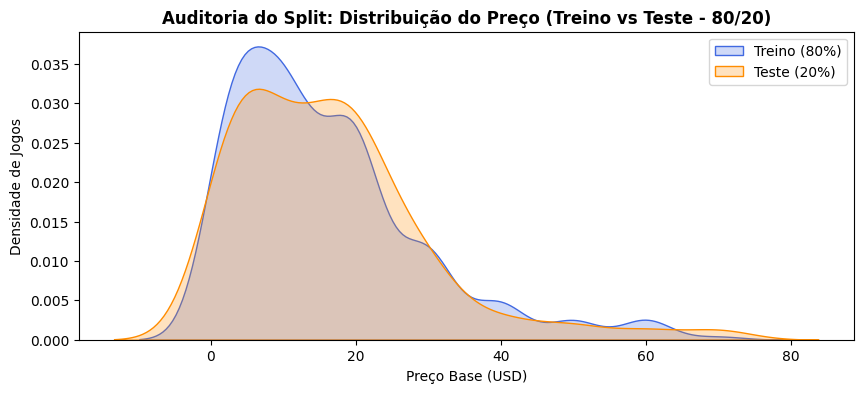

In [6]:
# Importações necessárias
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

print("--- CENÁRIO 1: SPLIT 80/20 ---")

# 1. Limpeza e definição das variáveis (Roda apenas uma vez)
colunas_drop = ['genres', 'developer', 'publisher', 'release_date', 'positive_reviews', 'negative_reviews', 'recommendations']
df_modelagem = df_processado.drop(columns=colunas_drop)

X = df_modelagem.drop(columns=['price_usd'])
y = df_modelagem['price_usd']

# 2. Train/Test Split (80% Treino, 20% Teste)
# Variáveis isoladas com o sufixo _80 e _20
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Separação 80/20 Concluída!")
print(f"➜ Dados de Treino (80%): {X_train_80.shape[0]} linhas")
print(f"➜ Dados de Teste (20%): {X_test_20.shape[0]} linhas\n")

# ==========================================
# VISUALIZAÇÃO: AUDITORIA DO SPLIT 80/20
# ==========================================
plt.figure(figsize=(10, 4))
sns.kdeplot(y_train_80, label='Treino (80%)', fill=True, color='royalblue')
sns.kdeplot(y_test_20, label='Teste (20%)', fill=True, color='darkorange')
plt.title('Auditoria do Split: Distribuição do Preço (Treino vs Teste - 80/20)', fontweight='bold')
plt.xlabel('Preço Base (USD)')
plt.ylabel('Densidade de Jogos')
plt.legend()
plt.show()

## SEÇÃO 5.2: SEPARAÇÃO DOS DADOS (TRAIN/TEST SPLIT - 70/30)

Seguindo as orientações de arquitetura para a Sprint 02 e visando testar diferentes cenários de viés e variância, vamos aplicar a divisão clássica de **70% para Treino** e **30% para Teste**. 

**Por que fazer isso antes do pré-processamento?**
Para evitar o *Data Leakage* (vazamento de dados). O nosso modelo e os nossos transformadores estatísticos (como o `StandardScaler`) devem aprender os padrões **apenas** com os dados de treino (70%). A base de teste (30%) deve permanecer isolada e "invisível" até o momento da validação final.

--- CENÁRIO 2: SPLIT 70/30 ---
Separação 70/30 Concluída!
➜ Dados de Treino (70%): 769 linhas
➜ Dados de Teste (30%): 330 linhas



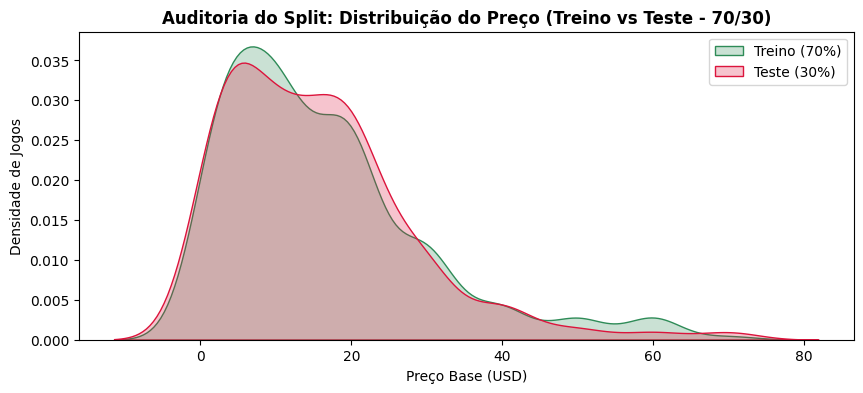

In [7]:
print("--- CENÁRIO 2: SPLIT 70/30 ---")

# 1. Train/Test Split (70% Treino, 30% Teste)
# Utilizamos os mesmos X e y, mas agora as variáveis de saída têm o sufixo _70 e _30
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(X, y, test_size=0.30, random_state=42)

print(f"Separação 70/30 Concluída!")
print(f"➜ Dados de Treino (70%): {X_train_70.shape[0]} linhas")
print(f"➜ Dados de Teste (30%): {X_test_30.shape[0]} linhas\n")

# ==========================================
# VISUALIZAÇÃO: AUDITORIA DO SPLIT 70/30
# ==========================================
plt.figure(figsize=(10, 4))
sns.kdeplot(y_train_70, label='Treino (70%)', fill=True, color='seagreen')
sns.kdeplot(y_test_30, label='Teste (30%)', fill=True, color='crimson')
plt.title('Auditoria do Split: Distribuição do Preço (Treino vs Teste - 70/30)', fontweight='bold')
plt.xlabel('Preço Base (USD)')
plt.ylabel('Densidade de Jogos')
plt.legend()
plt.show()

### Cenário 5.3: Arquitetura com Validação (60% Treino / 20% Validação / 20% Teste)

Para este último cenário, implementamos uma arquitetura de três conjuntos, recomendada para um controlo rigoroso sobre o *bias* (viés) e a *variance* (variância):
* **Treino (60%):** A base principal onde o algoritmo aprenderá os padrões matemáticos.
* **Validação (20%):** O ambiente de calibração. Utilizaremos esta base na Sprint 03 para afinar hiperparâmetros e monitorizar o *overfitting*, garantindo que não tocamos na base de teste.
* **Teste (20%):** O nosso "cofre". Um conjunto intocável que servirá apenas para a avaliação final de desempenho do modelo.

Para garantir esta divisão com a função `train_test_split`, realizamos o corte em duas fases, preservando sempre a semente aleatória (`random_state=42`) para garantir a reprodutibilidade.### Cenário 3: Arquitetura com Validação (60% Treino / 20% Validação / 20% Teste)

Após compararmos as distribuições nos três cenários (80/20, 70/30 e 60/20/20), decidimos adotar o **60/20/20** como a arquitetura definitiva para a modelagem na Sprint 03. 

**Por que escolhemos essa abordagem?**
Como a nossa base tem um volume considerável de jogos, abrir mão de uma parte do Treino para criar um conjunto isolado de Validação (20%) é a estratégia mais robusta. Isso nos dá um ambiente exclusivo para calibrar os hiperparâmetros dos modelos sem causar *data leakage* (vazamento de dados) ou viciar o algoritmo. 

Dessa forma, o conjunto de Teste (20%) permanece totalmente isolado ("trancado no cofre") até o final, garantindo que a nossa métrica de erro reflita a capacidade real de generalização da IA em dados inéditos.

Abaixo, fazemos a separação em duas etapas, preservando a semente aleatória (`random_state=42`) para garantir a reprodutibilidade.

--- 5.4 SELEÇÃO E SEPARAÇÃO DE DADOS () 60/20/20) ---
✅ Separação 60/20/20 Concluída!
➜ Treino (60%): 659 linhas
➜ Validação (20%): 220 linhas
➜ Teste (20%): 220 linhas



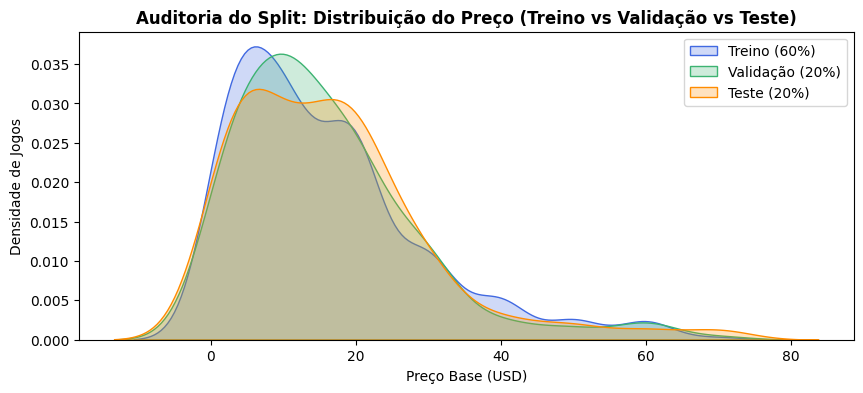

In [8]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 5.4 SELEÇÃO E SEPARAÇÃO DE DADOS () 60/20/20) ---")

# 1. Limpeza: Remover colunas redundantes que não vão para o modelo
colunas_drop = ['genres', 'developer', 'publisher', 'release_date', 'positive_reviews', 'negative_reviews', 'recommendations']
df_modelagem = df_processado.drop(columns=colunas_drop)

# 2. Separando X (Previsores) e y (Alvo)
X = df_modelagem.drop(columns=['price_usd'])
y = df_modelagem['price_usd']

# 3. Train/Val/Test Split (60% Treino, 20% Validação, 20% Teste)
# Primeiro corte: separa 20% para o Teste Final (Cofre)
X_temp, X_test_20_c3, y_temp, y_test_20_c3 = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Segundo corte: dos 80% restantes (X_temp), tiramos 25% para Validação (o que equivale a 20% do total)
X_train_60, X_val_20, y_train_60, y_val_20 = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

print(f"✅ Separação 60/20/20 Concluída!")
print(f"➜ Treino (60%): {X_train_60.shape[0]} linhas")
print(f"➜ Validação (20%): {X_val_20.shape[0]} linhas")
print(f"➜ Teste (20%): {X_test_20_c3.shape[0]} linhas\n")

# ==========================================
# VISUALIZAÇÃO: AUDITORIA DO SPLIT 60/20/20
# ==========================================
plt.figure(figsize=(10, 4))
sns.kdeplot(y_train_60, label='Treino (60%)', fill=True, color='royalblue')
sns.kdeplot(y_val_20, label='Validação (20%)', fill=True, color='mediumseagreen')
sns.kdeplot(y_test_20_c3, label='Teste (20%)', fill=True, color='darkorange')

plt.title('Auditoria do Split: Distribuição do Preço (Treino vs Validação vs Teste)', fontweight='bold')
plt.xlabel('Preço Base (USD)')
plt.ylabel('Densidade de Jogos')
plt.legend()
plt.show()

### 5.4 Conclusão dos testes

Após compararmos as distribuições nos três cenários (80/20, 70/30 e 60/20/20), decidimos adotar o **60/20/20** como a arquitetura definitiva para a modelagem na Sprint 03. 

**Por que escolhemos essa abordagem?**
Como a nossa base tem um volume considerável de jogos, abrir mão de uma parte do Treino para criar um conjunto isolado de Validação (20%) é a estratégia mais robusta. Isso nos dá um ambiente exclusivo para calibrar os hiperparâmetros dos modelos sem causar *data leakage* (vazamento de dados) ou viciar o algoritmo. 

Dessa forma, o conjunto de Teste (20%) permanece totalmente isolado ("trancado no cofre") até o final, garantindo que a nossa métrica de erro reflita a capacidade real de generalização da IA em dados inéditos.

## SEÇÃO 6: PIPELINE DE PRÉ-PROCESSAMENTO AVANÇADO (CENÁRIO 60/20/20)

Nesta etapa, vamos consolidar o tratamento de dados utilizando o `ColumnTransformer` do Scikit-Learn. Esta ferramenta permite-nos aplicar transformações diferentes consoante o tipo de dado:
* **Features Numéricas:** Preenchimento de nulos com a mediana (`SimpleImputer`) e padronização das escalas para média 0 e desvio padrão 1 (`StandardScaler`).
* **Features Categóricas:** Preenchimento de nulos com o valor mais frequente e transformação em variáveis binárias independentes (`OneHotEncoder`).

Para garantir a ausência total de *Data Leakage* na nossa arquitetura de três conjuntos, aplicamos a seguinte regra estrita:
1. **Treino (60%):** Usamos o `.fit_transform()` para o pipeline "aprender" as regras estatísticas.
2. **Validação (20%) e Teste (20%):** Usamos apenas o `.transform()`. O pipeline não aprende nada novo com estes conjuntos, apenas aplica as regras aprendidas no Treino.

--- 6. APLICANDO O PIPELINE DE MACHINE LEARNING (60/20/20) ---
Pipeline construído e aplicado com sucesso aos três conjuntos!



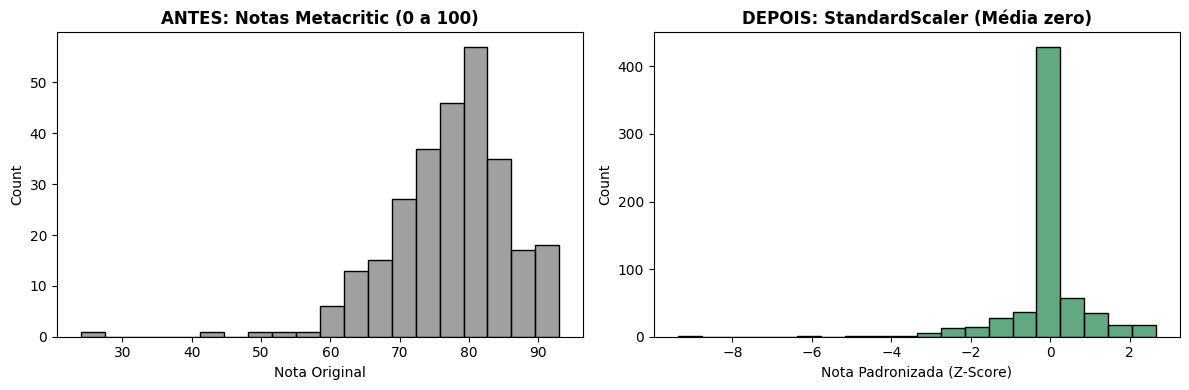

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 6. APLICANDO O PIPELINE DE MACHINE LEARNING (60/20/20) ---")

# As nossas features finais (incluindo as geradas na Seção 4!)
features_numericas = ['metacritic_score', 'genre_count', 'release_year', 'approval_rating']
features_categoricas = ['publishing_model']

# 1. Pipeline Numérico
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. Pipeline Categórico
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 3. Juntando tudo num processador único
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features_numericas),
        ('cat', categorical_transformer, features_categoricas)
    ])

# 4. Aplicação à prova de Data Leakage (Fit SÓ no treino de 60%!)
X_train_processado_60 = preprocessor.fit_transform(X_train_60)

# O transform ocorre na Validação e no Teste (aplicando as mesmas regras do Treino)
X_val_processado_20 = preprocessor.transform(X_val_20)
X_test_processado_20 = preprocessor.transform(X_test_20_c3)

print("Pipeline construído e aplicado com sucesso aos três conjuntos!\n")

# ==========================================
# VISUALIZAÇÃO: EFEITO DO SCALER
# ==========================================
# Vamos mostrar o antes e depois da coluna 'metacritic_score'
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ANTES: Dados originais do Treino (60%)
sns.histplot(X_train_60['metacritic_score'].dropna(), color='gray', bins=20, ax=axes[0])
axes[0].set_title('ANTES: Notas Metacritic (0 a 100)', fontweight='bold')
axes[0].set_xlabel('Nota Original')

# DEPOIS: A mesma coluna após o StandardScaler ser aplicado no Pipeline
# Nota: Como 'metacritic_score' é a primeira lista em 'features_numericas', ela vira a coluna índice 0 no array processado
sns.histplot(X_train_processado_60[:, 0], color='seagreen', bins=20, ax=axes[1])
axes[1].set_title('DEPOIS: StandardScaler (Média zero)', fontweight='bold')
axes[1].set_xlabel('Nota Padronizada (Z-Score)')

plt.tight_layout()
plt.show()

## SEÇÃO 7: RESUMO EXECUTIVO E EXPORTAÇÃO DOS DADOS (CENÁRIO 60/20/20)

**Objetivo:** Documentar todas as transformações realizadas nesta Sprint para facilitar a auditoria do modelo e exportar os conjuntos isolados de Treino, Validação e Teste (ponto de partida para a Sprint 3).

### 📊 Tabela de Transformações (O que fizemos e Porquê)

| Variável Original | Ação / Transformação | Justificativa Técnica e de Negócio |
| :--- | :--- | :--- |
| `app_id`, `name`, `header_image` | Remoção (Drop) | Não possuem poder preditivo e servem apenas como identificação estética. |
| `price_usd` (Alvo) | Corte de Outliers (Regra de Negócio) | Remoção de jogos gratuitos ($0) e aplicação de um teto de mercado (USD 90.00). Isso evita que o modelo seja distorcido por edições de luxo irreais, mas garante que a IA aprenda a precificar jogos de alto orçamento (AAA). |
| `genres` | Eng. de Variável (`genre_count`) | Jogos com muitos géneros combinados costumam ser projetos mais complexos e caros. |
| `developer` / `publisher` | Eng. de Variável (`publishing_model`) | Distinguir jogos Independentes de jogos com financiamento de uma Editora (Publisher). |
| `release_date` | Eng. de Variável (`release_year`) | Isolar o ano ajuda o algoritmo a capturar a inflação dos preços do mercado de *games* ao longo do tempo. |
| `positive_reviews`, `negative_reviews`, `recommendations` | Remoção (Drop) | Retiradas para evitar redundância (Data Leakage) após a criação da métrica consolidada de aprovação. |
| `approval_rating` (Nova) | Feature Engineering | Traduz a aceitação da comunidade num único valor percentual (0 a 1), facilitando muito o aprendizado do algoritmo. |
| `metacritic_score` | Pipeline: SimpleImputer (Mediana) | Preencher as notas em falta com uma métrica robusta contra extremos, evitando perder quase 50% do dataset. |
| Variáveis Numéricas | Pipeline: StandardScaler | Padronizar grandezas diferentes (Ano vs. Nota vs. Aprovação) na mesma escala de peso estatístico. |
| `publishing_model` | Pipeline: One-Hot Encoding | Traduzir texto em valores binários (0 e 1) exigidos pelas equações de *Machine Learning*. |

### Estratégia de Exportação (Prevenção de *Data Leakage*)
Para garantir que a Sprint 03 inicie com os dados perfeitamente isolados, vamos exportar os três conjuntos definidos na nossa arquitetura (**60% Treino, 20% Validação, 20% Teste**) em ficheiros CSV separados.

**Nota de Arquitetura:**
Estamos a exportar os conjuntos **antes** da aplicação final do `ColumnTransformer` (Pipeline). Esta decisão mantém os ficheiros CSV legíveis e com os nomes das colunas intactos. Na Sprint 03, o nosso *pipeline* de pré-processamento será encapsulado e aplicado dinamicamente no momento do treino dos algoritmos (Random Forest, XGBoost), integrando-se perfeitamente com o `GridSearchCV`.

In [12]:
import os
import pandas as pd

print("--- 7. EXPORTAÇÃO DOS DATASETS (60/20/20) ---")

# 1. Criar a pasta para organizar os dados da Sprint 02 (caso não exista)
os.makedirs('data/Sprint_02', exist_ok=True)

# 2. Reconstruir os DataFrames (juntando as features X com o alvo y)
# Fazemos uma cópia para não alterar as variáveis que estão na memória
df_train_final = X_train_60.copy()
df_train_final['price_usd'] = y_train_60

df_val_final = X_val_20.copy()
df_val_final['price_usd'] = y_val_20

df_test_final = X_test_20_c3.copy()
df_test_final['price_usd'] = y_test_20_c3

# 3. Definir os caminhos dos ficheiros
caminho_train = 'data/Sprint_02/steam_train_60.csv'
caminho_val = 'data/Sprint_02/steam_val_20.csv'
caminho_test = 'data/Sprint_02/steam_test_20.csv'

# 4. Guardar os DataFrames em formato CSV
df_train_final.to_csv(caminho_train, index=False)
df_val_final.to_csv(caminho_val, index=False)
df_test_final.to_csv(caminho_test, index=False)

print(f"Sucesso! Os datasets foram guardados e estão prontos para a Sprint 03.")
print(f"➜ Treino: {df_train_final.shape[0]} linhas guardadas em '{caminho_train}'")
print(f"➜ Validação: {df_val_final.shape[0]} linhas guardadas em '{caminho_val}'")
print(f"➜ Teste: {df_test_final.shape[0]} linhas guardadas em '{caminho_test}'\n")

--- 7. EXPORTAÇÃO DOS DATASETS (60/20/20) ---
Sucesso! Os datasets foram guardados e estão prontos para a Sprint 03.
➜ Treino: 659 linhas guardadas em 'data/Sprint_02/steam_train_60.csv'
➜ Validação: 220 linhas guardadas em 'data/Sprint_02/steam_val_20.csv'
➜ Teste: 220 linhas guardadas em 'data/Sprint_02/steam_test_20.csv'

